# Sentiment Analysis with RoBERTa

In this notebook, we implement a Transformer-based sentiment classifier using RoBERTa.

We train and evaluate the model on three different datasets:
- 1K Amazon Reviews
- 25K Amazon Reviews
- Video Game Reviews

Each dataset is processed and evaluated independently using the same pipeline.

## Setup & Imports

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import wandb

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from utils import device_check
from transformer_utils import (
    build_tf_datasets,
    compute_metrics_tf,
    WeightedTrainer,
    evaluate_tf,
    plot_confusion_matrix_tf,
)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [2]:
LOG_WANDB = True
SEED      = 1

# Assumes the notebook is launched from Lab1/src.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR  = NOTEBOOK_DIR.parent
WANDB_DIR    = PROJECT_DIR
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'
MODELS_DIR   = PROJECT_DIR / 'models'

MODEL_NAME = 'roberta-base'
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# wandb project/entity are read from env vars by Trainer and wandb.init.
os.environ['WANDB_PROJECT'] = 'Lab1'
os.environ['WANDB_ENTITY']  = 'd7047e-group12'
os.environ['WANDB_DIR']     = str(WANDB_DIR)

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

---
## Initial Test — 1K Amazon Reviews

### Load Pre-split Data

In [3]:
train_df = pd.read_csv(SPLITS_DIR / '1k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '1k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '1k_test.csv')

text_col  = 'Sentence'
label_col = 'Class'

NUM_LABELS  = 2
NUM_CLASSES = 2

### Tokenizer & Datasets

In [4]:
datasets = build_tf_datasets(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
)

### Model

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training using a `Trainer`

The `Trainer` handles the epoch loop, AMP, warmup scheduling, gradient clipping, best-checkpoint restoration, and wandb logging. `compute_metrics_tf` adds accuracy and macro/weighted F1 to every eval step.

In [6]:
BATCH_SIZE    = 64
NUM_WORKERS   = 16
NUM_EPOCHS    = 5
LEARNING_RATE = 2e-5
WARMUP_STEPS  = int(0.1 * NUM_EPOCHS * len(datasets['train']) / BATCH_SIZE)
RUN_NAME      = 'RoBERTA 1K'
OUT_DIR       = MODELS_DIR / 'roberta_1k'

wandb.init(
    name=RUN_NAME,
    tags=['Task 1.2', 'RoBERTa', 'Transformer', '1K', 'Trainer'],
    config={
        'dataset':      'Amazon 1K',
        'model_name':   MODEL_NAME,
        'optimizer':    'AdamW',
        'lr':           LEARNING_RATE,
        'epochs':       NUM_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'max_length':   MAX_LENGTH,
        'warmup_steps': WARMUP_STEPS,
    },
    reinit=True,
    mode='online' if LOG_WANDB else 'disabled',
)

training_args = TrainingArguments(
    output_dir=str(OUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    fp16=torch.cuda.is_available(),
    torch_compile=torch.cuda.is_available(),
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_strategy='epoch',
    dataloader_num_workers=NUM_WORKERS,
    report_to=['wandb'] if LOG_WANDB else 'none',
    run_name=RUN_NAME,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=datasets['train'],
    eval_dataset=datasets['val'],
    compute_metrics=compute_metrics_tf,
    processing_class=tokenizer,
)

trainer.train()
trainer.save_model(str(OUT_DIR))

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


The speedups for torchdynamo mostly come with GPU Ampere or higher and which is not detected here.
/usr/local/lib/python3.11/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.693743,0.675412,0.800000,0.799604,0.799604
2,0.604743,0.416873,0.933333,0.933333,0.933333
3,0.258022,0.202176,0.922222,0.922213,0.922213
4,0.131297,0.180587,0.933333,0.933300,0.933300
5,0.109760,0.185448,0.944444,0.944438,0.944438


/usr/local/lib/python3.11/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Test-Set Evaluation & Confusion Matrix

In [7]:
_, y_true, y_pred = evaluate_tf(
    trainer,
    datasets['test'],
    label='RoBERTa-1K',
    class_names=['Negative', 'Positive'],
)

Classification Report: RoBERTa-1K

              precision    recall  f1-score   support

    Negative      0.979     0.920     0.948        50
    Positive      0.925     0.980     0.951        50

    accuracy                          0.950       100
   macro avg      0.952     0.950     0.950       100
weighted avg      0.952     0.950     0.950       100

Trainer metrics:
  test_loss: 0.1891
  test_accuracy: 0.9500
  test_macro_f1: 0.9500
  test_weighted_f1: 0.9500
  test_runtime: 0.9622
  test_samples_per_second: 103.9270
  test_steps_per_second: 1.0390


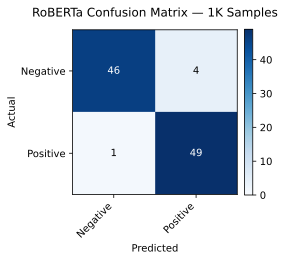

eval/accuracy,▁▇▇▇█
eval/loss,█▄▁▁▁
eval/macro_f1,▁▇▇▇█
eval/runtime,▄▁▆██
eval/samples_per_second,▄█▂▁▁
eval/steps_per_second,▄█▂▁▁
eval/weighted_f1,▁▇▇▇█
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
+9,...


In [8]:
plot_confusion_matrix_tf(
    y_true,
    y_pred,
    NUM_CLASSES,
    ['Negative', 'Positive'],
    'RoBERTa Confusion Matrix — 1K Samples',
)

wandb.finish()

---
## Scaling Up — 25K Amazon Reviews

### Load Pre-split Data

In [9]:
train_df = pd.read_csv(SPLITS_DIR / '25k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '25k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '25k_test.csv')

text_col  = 'Sentence'
label_col = 'Class'

NUM_LABELS  = 2
NUM_CLASSES = 2

### Tokenizer & Datasets

In [10]:
datasets = build_tf_datasets(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
)

### Model

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

In [12]:
BATCH_SIZE    = 64
NUM_WORKERS   = 16
NUM_EPOCHS    = 5
LEARNING_RATE = 2e-5
WARMUP_STEPS  = int(0.1 * NUM_EPOCHS * len(datasets['train']) / BATCH_SIZE)
RUN_NAME      = 'RoBERTa 25K'
OUT_DIR       = MODELS_DIR / 'roberta_25k'

wandb.init(
    name=RUN_NAME,
    tags=['Task 1.2', 'RoBERTa', 'Transformer', '25K', 'Trainer'],
    config={
        'dataset':      'Amazon 25K',
        'model_name':   MODEL_NAME,
        'optimizer':    'AdamW',
        'lr':           LEARNING_RATE,
        'epochs':       NUM_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'max_length':   MAX_LENGTH,
        'warmup_steps': WARMUP_STEPS,
    },
    reinit=True,
    mode='online' if LOG_WANDB else 'disabled',
)

training_args = TrainingArguments(
    output_dir=str(OUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    fp16=torch.cuda.is_available(),
    torch_compile=torch.cuda.is_available(),
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_strategy='epoch',
    dataloader_num_workers=NUM_WORKERS,
    report_to=['wandb'] if LOG_WANDB else 'none',
    run_name=RUN_NAME,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=datasets['train'],
    eval_dataset=datasets['val'],
    compute_metrics=compute_metrics_tf,
    processing_class=tokenizer,
)

trainer.train()
trainer.save_model(str(OUT_DIR))

The speedups for torchdynamo mostly come with GPU Ampere or higher and which is not detected here.
/usr/local/lib/python3.11/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.311175,0.173327,0.946667,0.944684,0.946871
2,0.153294,0.158127,0.946222,0.943647,0.946163
3,0.105993,0.164440,0.950667,0.948157,0.950540
4,0.076531,0.190827,0.951111,0.948881,0.951111
5,0.058226,0.205169,0.951556,0.949133,0.951452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Test-Set Evaluation & Confusion Matrix

In [13]:
_, y_true, y_pred = evaluate_tf(
    trainer,
    datasets['test'],
    label='RoBERTa-25K',
    class_names=['Negative', 'Positive'],
)

Classification Report: RoBERTa-25K

              precision    recall  f1-score   support

    Negative      0.928     0.930     0.929       988
    Positive      0.954     0.953     0.954      1512

    accuracy                          0.944      2500
   macro avg      0.941     0.942     0.941      2500
weighted avg      0.944     0.944     0.944      2500

Trainer metrics:
  test_loss: 0.1716
  test_accuracy: 0.9440
  test_macro_f1: 0.9414
  test_weighted_f1: 0.9440
  test_runtime: 2.7986
  test_samples_per_second: 893.2890
  test_steps_per_second: 7.1460


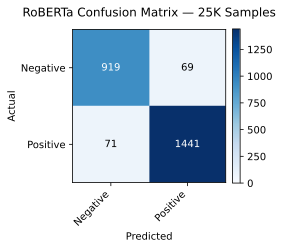

eval/accuracy,▂▁▇▇█
eval/loss,▃▁▂▆█
eval/macro_f1,▂▁▇██
eval/runtime,▁▂▇█▇
eval/samples_per_second,█▇▂▁▂
eval/steps_per_second,█▇▂▁▂
eval/weighted_f1,▂▁▇██
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
+9,...


In [14]:
plot_confusion_matrix_tf(
    y_true,
    y_pred,
    NUM_CLASSES,
    ['Negative', 'Positive'],
    'RoBERTa Confusion Matrix — 25K Samples',
)

wandb.finish()

---
## Video Game Reviews — 5-Class Rating

### Load Pre-split Data

In [15]:
train_df = pd.read_csv(SPLITS_DIR / 'vg_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / 'vg_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / 'vg_test.csv')

text_col  = 'Sentence'
label_col = 'Class'

# Convert labels from 1-5 → 0-4
train_df[label_col] = train_df[label_col].astype(int) - 1
val_df[label_col]   = val_df[label_col].astype(int) - 1
test_df[label_col]  = test_df[label_col].astype(int) - 1

NUM_LABELS  = 5
NUM_CLASSES = 5

### Tokenizer & Datasets

In [16]:
datasets = build_tf_datasets(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
)

### Model

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training using `WeightedTrainer`

The Video Game split is ~58% 5-star, so we use inverse-frequency class weights via `WeightedTrainer` and enable label smoothing through `TrainingArguments.label_smoothing_factor`.

In [18]:
BATCH_SIZE      = 64
NUM_WORKERS     = 16
NUM_EPOCHS      = 5
LEARNING_RATE   = 2e-5
WARMUP_STEPS    = int(0.1 * NUM_EPOCHS * len(datasets['train']) / BATCH_SIZE)
LABEL_SMOOTHING = 0.1
RUN_NAME        = 'RoBERTa VG'
OUT_DIR         = MODELS_DIR / 'roberta_vg'

# Inverse-frequency class weights to counter the ~58% 5-star imbalance
class_counts = np.bincount(np.asarray(train_df[label_col], dtype=np.int64))
class_weights = torch.tensor(
    (1.0 / class_counts) / (1.0 / class_counts).sum() * len(class_counts),
    dtype=torch.float,
)

wandb.init(
    name=RUN_NAME,
    tags=['Task 1.2', 'RoBERTa', 'Transformer', 'VG', 'Trainer'],
    config={
        'dataset':          'Video Games',
        'model_name':       MODEL_NAME,
        'optimizer':        'AdamW',
        'lr':               LEARNING_RATE,
        'epochs':           NUM_EPOCHS,
        'batch_size':       BATCH_SIZE,
        'max_length':       MAX_LENGTH,
        'warmup_steps':     WARMUP_STEPS,
        'label_smoothing':  LABEL_SMOOTHING,
        'class_weights':    class_weights.tolist(),
    },
    reinit=True,
    mode='online' if LOG_WANDB else 'disabled',
)

training_args = TrainingArguments(
    output_dir=str(OUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    label_smoothing_factor=LABEL_SMOOTHING,
    fp16=torch.cuda.is_available(),
    torch_compile=torch.cuda.is_available(),
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_strategy='epoch',
    dataloader_num_workers=NUM_WORKERS,
    report_to=['wandb'] if LOG_WANDB else 'none',
    run_name=RUN_NAME,
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=datasets['train'],
    eval_dataset=datasets['val'],
    compute_metrics=compute_metrics_tf,
    processing_class=tokenizer,
    class_weights=class_weights,
)

trainer.train()
trainer.save_model(str(OUT_DIR))

The speedups for torchdynamo mostly come with GPU Ampere or higher and which is not detected here.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.303710,1.259419,0.689735,0.583864,0.709342
2,1.241234,1.242718,0.701095,0.598109,0.718250
3,1.204416,1.240758,0.702279,0.601255,0.720041
4,1.164771,1.259058,0.712217,0.607857,0.727588
5,1.127261,1.276638,0.714276,0.609056,0.729094


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Test-Set Evaluation & Confusion Matrix

In [19]:
_, y_true, y_pred = evaluate_tf(
    trainer,
    datasets['test'],
    label='RoBERTa-VG',
    class_names=['1-star', '2-star', '3-star', '4-star', '5-star'],
)

Classification Report: RoBERTa-VG

              precision    recall  f1-score   support

      1-star      0.811     0.723     0.765     31181
      2-star      0.377     0.555     0.449     14131
      3-star      0.438     0.552     0.488     21230
      4-star      0.419     0.544     0.474     41225
      5-star      0.910     0.781     0.840    148587

    accuracy                          0.704    256354
   macro avg      0.591     0.631     0.603    256354
weighted avg      0.751     0.704     0.721    256354

Trainer metrics:
  test_loss: 1.2412
  test_accuracy: 0.7043
  test_macro_f1: 0.6032
  test_weighted_f1: 0.7215
  test_runtime: 171.9909
  test_samples_per_second: 1490.5090
  test_steps_per_second: 11.6460


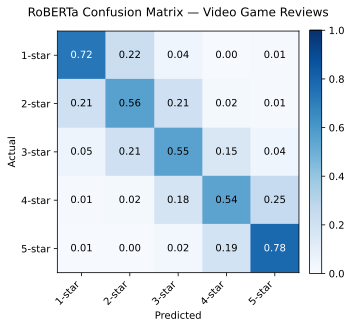

eval/accuracy,▁▄▅▇█
eval/loss,▅▁▁▅█
eval/macro_f1,▁▅▆██
eval/runtime,▆█▁▃▁
eval/samples_per_second,▃▁█▆█
eval/steps_per_second,▃▁█▆█
eval/weighted_f1,▁▄▅▇█
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
+9,...


In [20]:
plot_confusion_matrix_tf(
    y_true,
    y_pred,
    NUM_CLASSES,
    ['1-star', '2-star', '3-star', '4-star', '5-star'],
    'RoBERTa Confusion Matrix — Video Game Reviews',
    normalize=True,
)

wandb.finish()